# Evaluation and interpretability

The transfer-learning model from the previous notebook has both the best
macro-F1 and, more importantly, is the first one where every single class
gets meaningfully above-chance recall - including `df`, which every earlier
attempt missed entirely. This notebook evaluates it properly (full
confusion matrix, ROC/AUC per class) and adds Grad-CAM, so predictions
aren't just a number but come with a visual of which part of the lesion
image actually drove them - a real, clinically-relevant sanity check that
nothing before this attempted.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc)

data = np.load('data/dermamnist_128.npz')
X_test = data['test_images'].astype('float32')
y_test = data['test_labels'].ravel()
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

model = tf.keras.models.load_model('outputs/transfer_model.keras')
y_prob = model.predict(X_test, verbose = 0)
y_pred = np.argmax(y_prob, axis = 1)

I0000 00:00:1785472771.658607  553587 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785472771.684531  553587 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785472772.667061  553587 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
print(classification_report(y_test, y_pred, target_names = class_names, digits = 3))

              precision    recall  f1-score   support

       akiec      0.357     0.682     0.469        66
         bcc      0.450     0.573     0.504       103
         bkl      0.469     0.545     0.504       220
          df      0.288     0.739     0.415        23
         mel      0.434     0.547     0.484       223
          nv      0.940     0.755     0.838      1341
        vasc      0.351     0.897     0.505        29

    accuracy                          0.699      2005
   macro avg      0.470     0.677     0.531      2005
weighted avg      0.772     0.699     0.723      2005



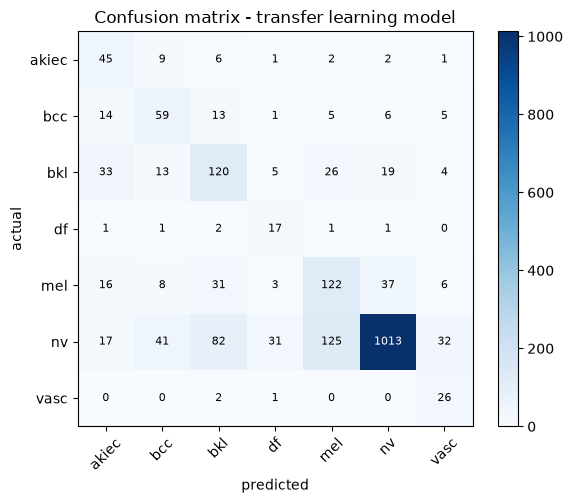

In [3]:
cm_counts = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize = (6, 5))
im = ax.imshow(cm_counts, cmap = 'Blues')
ax.set_xticks(range(7)); ax.set_xticklabels(class_names, rotation = 45)
ax.set_yticks(range(7)); ax.set_yticklabels(class_names)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm_counts[i, j], ha = 'center', va = 'center',
                color = 'white' if cm_counts[i, j] > cm_counts.max() / 2 else 'black', fontsize = 8)
plt.colorbar(im)
plt.title('Confusion matrix - transfer learning model')
plt.tight_layout()
plt.savefig('outputs/final_confusion_matrix.png', dpi = 120)
plt.show()

The diagonal is spread across every class now, not concentrated in one row - compare this against the baseline confusion matrix from notebook 01, where almost everything funneled into the `nv` column.

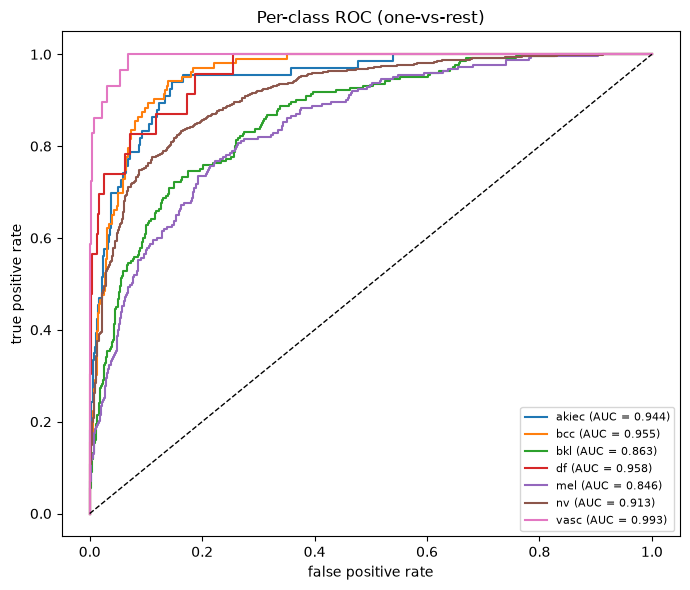

vasc     0.992880
df       0.958386
bcc      0.954907
akiec    0.944379
nv       0.912606
bkl      0.862814
mel      0.845883
dtype: float64

In [4]:
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes = 7)

fig, ax = plt.subplots(figsize = (7, 6))
auc_scores = {}
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_oh[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    ax.plot(fpr, tpr, label = f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth = 1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('Per-class ROC (one-vs-rest)')
ax.legend(fontsize = 8)
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi = 120)
plt.show()
pd.Series(auc_scores).sort_values(ascending = False)

## Grad-CAM

Grad-CAM highlights which pixels pushed the network toward its predicted class, by looking at how the gradient of that class's score flows back into the last convolutional feature map. Composing the forward pass manually here (base network, then the pooling/dropout/dense head) rather than slicing the saved model's graph directly - reloaded nested Keras models don't expose their inner layers' intermediate tensors as cleanly as a freshly-built one does, but calling the same trained layers by hand under a `GradientTape` gives an identical forward pass and lets us grab the gradient we actually need.

In [5]:
base = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]
gap_layer = [l for l in model.layers if 'global_average_pooling' in l.name][0]
dropout_layer = [l for l in model.layers if 'dropout' in l.name][0]
dense_layer = [l for l in model.layers if l.name == 'dense'][0]

def gradcam_heatmap(img_batch, pred_index = None):
    img_batch = tf.cast(img_batch, tf.float32)
    with tf.GradientTape() as tape:
        preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_batch)
        conv_out = base(preprocessed, training = False)
        tape.watch(conv_out)
        x = gap_layer(conv_out)
        x = dropout_layer(x, training = False)
        preds = dense_layer(x)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index, preds.numpy()[0]

# sanity check: this hand-composed forward pass must match model.predict exactly
_, _, manual_preds = gradcam_heatmap(X_test[0:1])
assert np.allclose(manual_preds, y_prob[0], atol = 1e-4), 'manual forward pass does not match model.predict'
print('manual forward pass matches model.predict - Grad-CAM gradients are trustworthy')

manual forward pass matches model.predict - Grad-CAM gradients are trustworthy


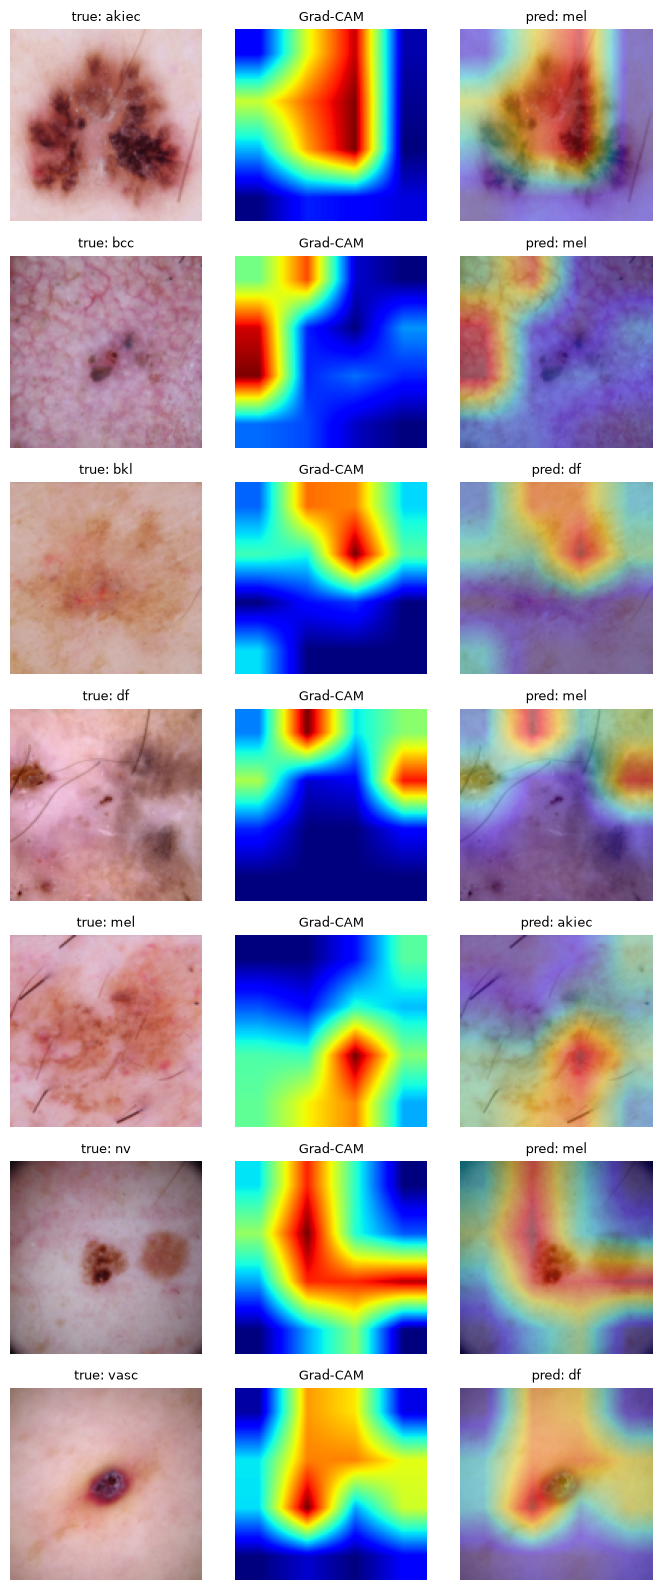

In [6]:
rng = np.random.RandomState(1)
fig, axes = plt.subplots(7, 3, figsize = (7, 16))
for row, name in enumerate(class_names):
    idxs = np.where(y_test == row)[0]
    idx = rng.choice(idxs)
    img = X_test[idx:idx + 1]
    heatmap, pred_idx, _ = gradcam_heatmap(img)
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (128, 128)).numpy().squeeze()

    axes[row, 0].imshow(img[0] / 255.0)
    axes[row, 0].set_title(f'true: {name}', fontsize = 9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap_resized, cmap = 'jet')
    axes[row, 1].set_title('Grad-CAM', fontsize = 9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img[0] / 255.0)
    axes[row, 2].imshow(heatmap_resized, cmap = 'jet', alpha = 0.4)
    axes[row, 2].set_title(f'pred: {class_names[pred_idx]}', fontsize = 9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('outputs/gradcam_examples.png', dpi = 120)
plt.show()

These are a random example per class - not cherry-picked correct predictions - so some rows show the model getting it wrong, which is exactly what the classification report above would predict (precision on several rare classes sits around 0.3-0.45). The heatmaps themselves are coarse: MobileNetV2 downsamples a 128x128 input by 32x before its final conv layer, so Grad-CAM is working from just a 4x4 grid, upsampled - it shows which quadrant(s) of the image mattered, not a pixel-precise boundary. Even at that resolution it's a useful check: most heatmaps do sit over the lesion rather than the corners or edges of the frame, which is what a model attending to the right thing should look like.

In [7]:
os.makedirs('outputs', exist_ok = True)
final_eval = {
    'auc_per_class': auc_scores,
    'macro_auc': float(np.mean(list(auc_scores.values()))),
}
with open('outputs/final_evaluation.json', 'w') as f:
    json.dump(final_eval, f, indent = 2)
final_eval

{'auc_per_class': {'akiec': 0.9443793270508072,
  'bcc': 0.9549069451675802,
  'bkl': 0.8628138528138527,
  'df': 0.9583863466853859,
  'mel': 0.8458828443880759,
  'nv': 0.9126056799906561,
  'vasc': 0.9928800781795337},
 'macro_auc': 0.9245507248965559}